# Problemas de regresión lineal: 

## Problema 1: Ley de Hubble 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [ ]:
#Leer CSV
df = pd.read_csv("hubble.csv")
print(df.head())

      Name  N_measurements  velocity  mean_m
0    Virgo               7       890    12.5
1  Pegasus               5      3810    15.5
2   Pisces               4      4630    15.4
3   Cancer               2      4820    16.0
4  Perseus               4      5230    16.4


In [ ]:
#Datos
import numpy as np

M = -13.8

df["distance"] = 10**((df["mean_m"] - M + 5)/5)

print(df.head())

from sklearn.linear_model import LinearRegression

X = df[["distance"]]
y = df["velocity"]

model = LinearRegression(fit_intercept=False)
model.fit(X, y)

H0 = model.coef_[0]

print("H0 =", H0)

      Name  N_measurements  velocity  mean_m      distance
0    Virgo               7       890    12.5  1.819701e+06
1  Pegasus               5      3810    15.5  7.244360e+06
2   Pisces               4      4630    15.4  6.918310e+06
3   Cancer               2      4820    16.0  9.120108e+06
4  Perseus               4      5230    16.4  1.096478e+07
H0 = 0.0005319332349587794


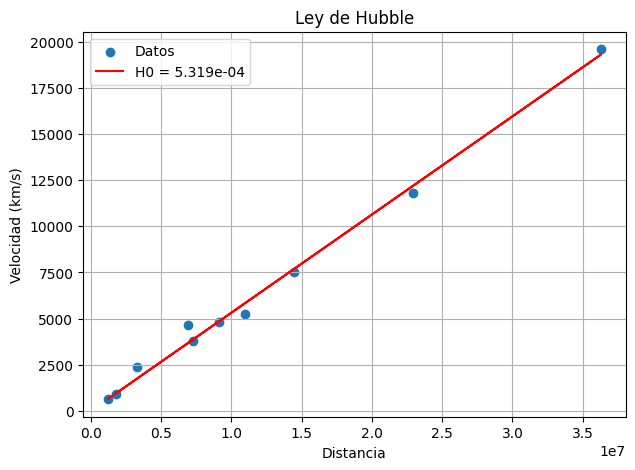

R² = 0.993657657015712


In [10]:
#Gráfcia comparativa 
y_pred = model.predict(X)

plt.figure(figsize=(7,5))
plt.scatter(df["distance"], df["velocity"], label="Datos")
plt.plot(df["distance"], y_pred,
         color="red",
         label=f"H0 = {H0:.3e}")

plt.xlabel("Distancia")
plt.ylabel("Velocidad (km/s)")
plt.title("Ley de Hubble")
plt.legend()
plt.grid()
plt.show()

print("R² =", r2_score(y, y_pred))

Se realizó un ajuste lineal entre la velocidad radial y la distancia estimada a partir de las magnitudes aparentes. La relación encontrada es altamente lineal, con un coeficiente de determinación $R^2=0.994$, 
lo que confirma la correlación observada originalmente por Hubble entre distancia y velocidad de recesión. La pendiente obtenida corresponde a una estimación de la constante de Hubble en las unidades empleadas por el conjunto de datos.
Seguramente la discrepancia se deba a un tema de unidades o a algún detalle menor en los datos, el hecho de que se ajusta bien a los datos me da más seguridad. No puedo encontrar el notebook correspondiente a esa clase para corroborar usar el M indicado o la basede datos indicada.

# Problema 2: Agujeros Negros Supermasivos (SMBHData)

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astropy.io import ascii

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

from scipy.integrate import quad

plt.rcParams["figure.figsize"] = (8,6)
plt.rcParams["axes.grid"] = True

In [5]:
# Funciones auxiliares

def resumen(df, nombre):
    print("="*60)
    print(nombre)
    print("="*60)
    print(f"Dimensiones: {df.shape}")
    display(df.head())


def ajustar_regresion(X, y):

    modelo = LinearRegression()

    modelo.fit(
        X.reshape(-1,1),
        y
    )

    return modelo


def evaluar_r2(modelo, X, y, tamaños):

    resultados = []

    for test_size in tamaños:

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=test_size,
            random_state=42
        )

        modelo.fit(X_train, y_train)

        pred = modelo.predict(X_test)

        resultados.append(
            r2_score(y_test, pred)
        )

    return np.array(resultados)

In [6]:
# Leer el catálogo

tabla = ascii.read(
    "data/SMBHData/table1.dat",
    readme="data/SMBHData/ReadMe"
)

datos = tabla.to_pandas()

resumen(datos, "Catálogo SMBH")

print(datos.columns.tolist())

Catálogo SMBH
Dimensiones: (88, 12)


,Name,z,sigma*,e_sigma*,n_sigma*,FWHM,e_FWHM,logL,e_logL,logM,E_logM,e_logM
0,SDSS J000805.62+145023.4,0.0454,140.0,27.0,NaN,7610,380,41.13,0.04,7.7,NaN,0.1
1,SDSS J004236.86-104921.8,0.0419,78.4,10.0,NaN,1960,97,41.58,0.14,6.7,NaN,0.1
2,SDSS J011703.58+000027.3,0.0456,98.8,16.0,NaN,2270,110,41.45,0.08,6.8,NaN,0.1
3,SDSS J020459.25-080816.0,0.0772,121.0,9.4,a,3720,180,41.13,0.05,7.0,NaN,0.1
4,SDSS J020615.99-001729.1,0.0426,216.0,30.0,NaN,3860,190,41.91,0.07,7.5,NaN,0.1


['Name', 'z', 'sigma*', 'e_sigma*', 'n_sigma*', 'FWHM', 'e_FWHM', 'logL', 'e_logL', 'logM', 'E_logM', 'e_logM']


In [7]:
# Preparar los datos para la primera regresión

modelo_1 = datos[
    ["sigma*", "logM"]
].copy()

modelo_1 = modelo_1.dropna()

print(f"Número de galaxias: {len(modelo_1)}")

modelo_1.head()

Número de galaxias: 88


,sigma*,logM
0,140.0,7.7
1,78.4,6.7
2,98.8,6.8
3,121.0,7.0
4,216.0,7.5


In [8]:
# Variables del modelo

X = modelo_1["sigma*"].to_numpy()

y = modelo_1["logM"].to_numpy()

print(f"Rango de sigma*: {X.min():.1f} - {X.max():.1f}")
print(f"Rango de logM:   {y.min():.2f} - {y.max():.2f}")

Rango de sigma*: 30.0 - 268.0
Rango de logM:   4.90 - 8.52


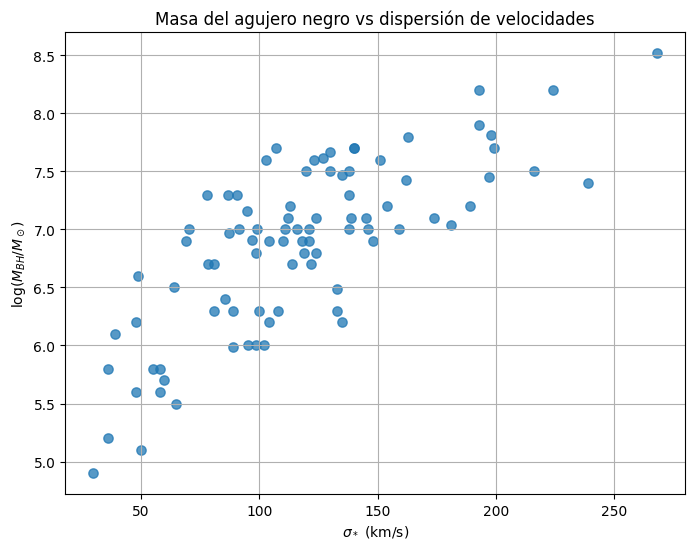

In [9]:
# Distribución de los datos

plt.figure(figsize=(8,6))

plt.scatter(
    X,
    y,
    s=45,
    alpha=0.75
)

plt.xlabel(r"$\sigma_*$ (km/s)")
plt.ylabel(r"$\log(M_{BH}/M_\odot)$")
plt.title("Masa del agujero negro vs dispersión de velocidades")

plt.show()

In [10]:
# Ajustar el modelo lineal

modelo = ajustar_regresion(X, y)

pendiente = modelo.coef_[0]
intercepto = modelo.intercept_

r2 = modelo.score(
    X.reshape(-1,1),
    y
)

print(f"Pendiente : {pendiente:.5f}")
print(f"Intercepto: {intercepto:.5f}")
print(f"R²        : {r2:.4f}")

Pendiente : 0.01136
Intercepto: 5.53578
R²        : 0.5671


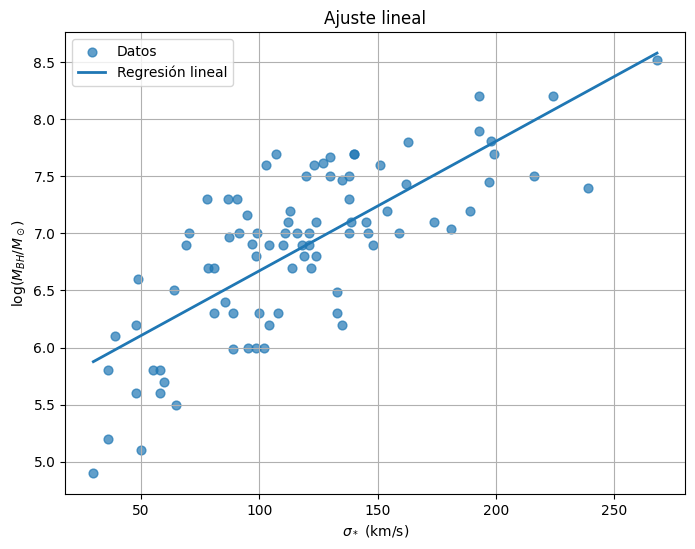

In [11]:
# Recta de regresión

x_fit = np.linspace(
    X.min(),
    X.max(),
    300
)

y_fit = modelo.predict(
    x_fit.reshape(-1,1)
)

plt.figure(figsize=(8,6))

plt.scatter(
    X,
    y,
    s=40,
    alpha=0.7,
    label="Datos"
)

plt.plot(
    x_fit,
    y_fit,
    linewidth=2,
    label="Regresión lineal"
)

plt.xlabel(r"$\sigma_*$ (km/s)")
plt.ylabel(r"$\log(M_{BH}/M_\odot)$")
plt.title("Ajuste lineal")
plt.legend()

plt.show()

In [12]:
# Preparar los datos para la regresión múltiple

modelo_multiple = datos[
    ["z", "sigma*", "FWHM", "logM"]
].copy()

modelo_multiple = modelo_multiple.dropna()

print(f"Número de galaxias: {len(modelo_multiple)}")

modelo_multiple.head()

Número de galaxias: 71


,z,sigma*,FWHM,logM
0,0.0454,140.0,7610,7.7
1,0.0419,78.4,1960,6.7
2,0.0456,98.8,2270,6.8
3,0.0772,121.0,3720,7.0
4,0.0426,216.0,3860,7.5


In [13]:
# Variables predictoras y objetivo

X = modelo_multiple[
    ["z", "sigma*", "FWHM"]
].values

y = modelo_multiple["logM"].values

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (71, 3)
Forma de y: (71,)


In [14]:
# División entrenamiento-prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42
)

print(f"Entrenamiento: {len(X_train)}")
print(f"Prueba: {len(X_test)}")

Entrenamiento: 53
Prueba: 18


In [15]:
# Modelos de regresión

modelos = {
    "Regresión Lineal": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01)
}

In [16]:
# Comparar desempeño de los modelos

resultados = {}

for nombre, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)

    resultados[nombre] = r2_score(
        y_test,
        pred
    )

for nombre, score in resultados.items():
    print(f"{nombre:20s}: R² = {score:.4f}")

Regresión Lineal    : R² = 0.7896
Ridge               : R² = 0.7672
Lasso               : R² = 0.7651


In [17]:
# Comparar desempeño de los modelos

resultados = {}

for nombre, modelo in modelos.items():

    modelo.fit(X_train, y_train)

    pred = modelo.predict(X_test)

    resultados[nombre] = r2_score(
        y_test,
        pred
    )

for nombre, score in resultados.items():
    print(f"{nombre:20s}: R² = {score:.4f}")

Regresión Lineal    : R² = 0.7896
Ridge               : R² = 0.7672
Lasso               : R² = 0.7651


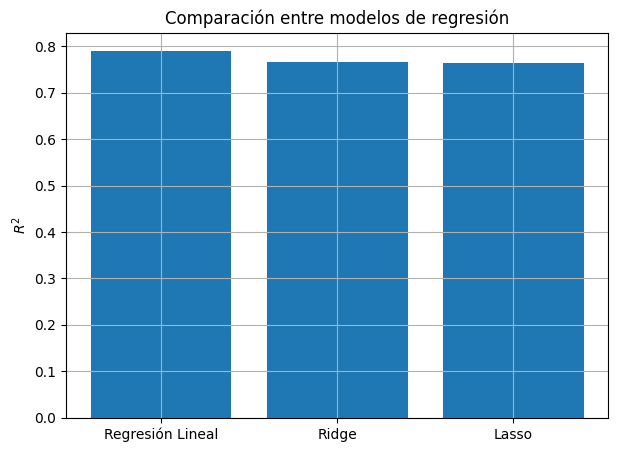

In [ ]:
# Comparación gráfica

plt.figure(figsize=(7,5))

plt.bar(
    resultados.keys(),
    resultados.values()
)

plt.ylabel(r"$R^2$")
plt.title("Comparación entre modelos de regresión")

plt.show()

In [19]:
# Tamaños del conjunto de prueba

test_sizes = np.linspace(0.1, 0.5, 9)

print(test_sizes)

[0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5 ]


In [20]:
# Evaluar los modelos para distintos tamaños de prueba

resultados_r2 = {}

for nombre, modelo in modelos.items():

    resultados_r2[nombre] = evaluar_r2(
        modelo,
        X,
        y,
        test_sizes
    )

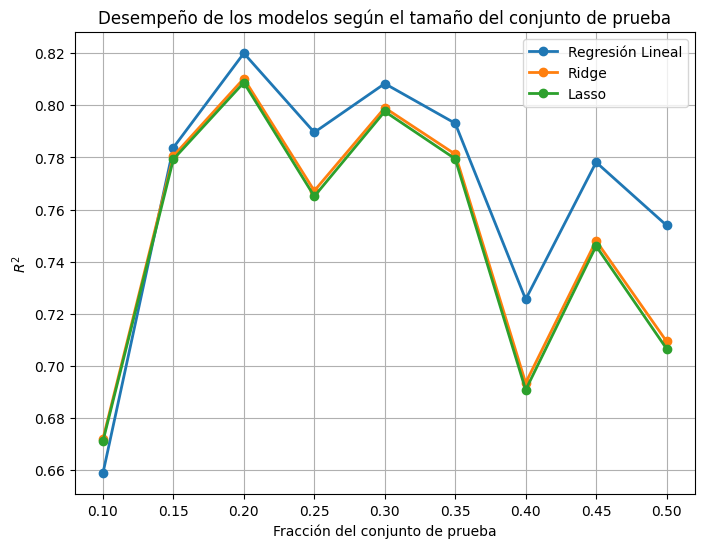

In [21]:
# Evolución del R²

plt.figure(figsize=(8,6))

for nombre, valores in resultados_r2.items():

    plt.plot(
        test_sizes,
        valores,
        marker="o",
        linewidth=2,
        label=nombre
    )

plt.xlabel("Fracción del conjunto de prueba")
plt.ylabel(r"$R^2$")
plt.title("Desempeño de los modelos según el tamaño del conjunto de prueba")

plt.legend()

plt.show()

In [22]:
# Resumen de resultados

tabla_resultados = pd.DataFrame(
    resultados_r2,
    index=np.round(test_sizes, 2)
)

tabla_resultados.index.name = "Test Size"

tabla_resultados

,Regresión Lineal,Ridge,Lasso
Test Size,,,
0.10,0.658822,0.671971,0.671093
0.15,0.783797,0.780581,0.779331
0.20,0.820014,0.810305,0.808761
0.25,0.789626,0.767210,0.765087
0.30,0.808353,0.799079,0.797657
0.35,0.793114,0.781261,0.779476
0.40,0.725556,0.693493,0.690791
0.45,0.778171,0.748050,0.746011
0.50,0.753943,0.709410,0.706605


In [23]:
# Estadísticas de desempeño

estadisticas = pd.DataFrame({
    "R² promedio": tabla_resultados.mean(),
    "Desviación estándar": tabla_resultados.std()
})

estadisticas

,R² promedio,Desviación estándar
Regresión Lineal,0.767933,0.049629
Ridge,0.751262,0.048955
Lasso,0.749424,0.049129


# Problema 3: Supernovas (Sinteticos)

In [26]:
# Cargar los datos

datos_cosmo = pd.read_csv("data/data/data_sample.csv")

resumen(datos_cosmo, "Datos de Supernovas")

Datos de Supernovas
Dimensiones: (200, 2)


,z_sample,mu_sample
0,0.574163,43.691174
1,0.739362,42.250323
2,0.622291,41.734378
3,0.570798,42.185804
4,0.473621,41.642052


In [27]:
# Variables del conjunto de datos

print(datos_cosmo.columns.tolist())

# Estadísticas descriptivas

datos_cosmo.describe()

# Valores faltantes

datos_cosmo.isna().sum()

['z_sample', 'mu_sample']


z_sample     0
mu_sample    0
dtype: int64

In [28]:
# Variables del modelo

z = datos_cosmo["z_sample"].values

mu = datos_cosmo["mu_sample"].values

print(f"Número de observaciones: {len(z)}")

Número de observaciones: 200


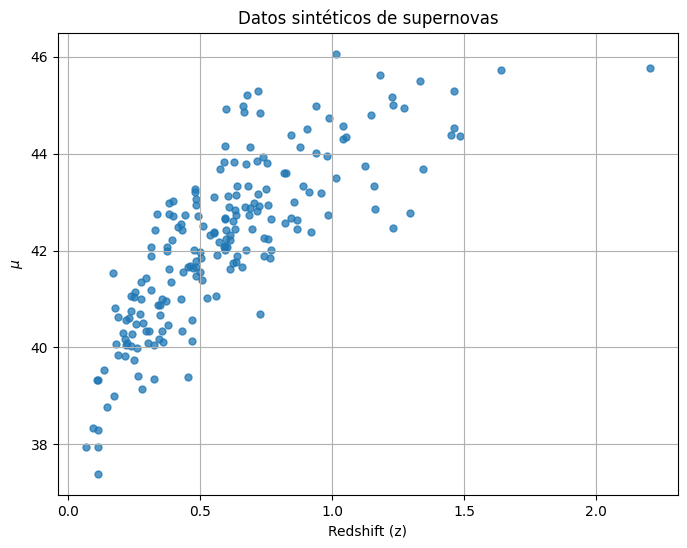

In [29]:
# Distribución de las supernovas

plt.figure(figsize=(8,6))

plt.scatter(
    z,
    mu,
    s=25,
    alpha=0.75
)

plt.xlabel("Redshift (z)")
plt.ylabel(r"$\mu$")
plt.title("Datos sintéticos de supernovas")

plt.show()

In [30]:
# Ordenar por redshift

orden = np.argsort(z)

z = z[orden]
mu = mu[orden]

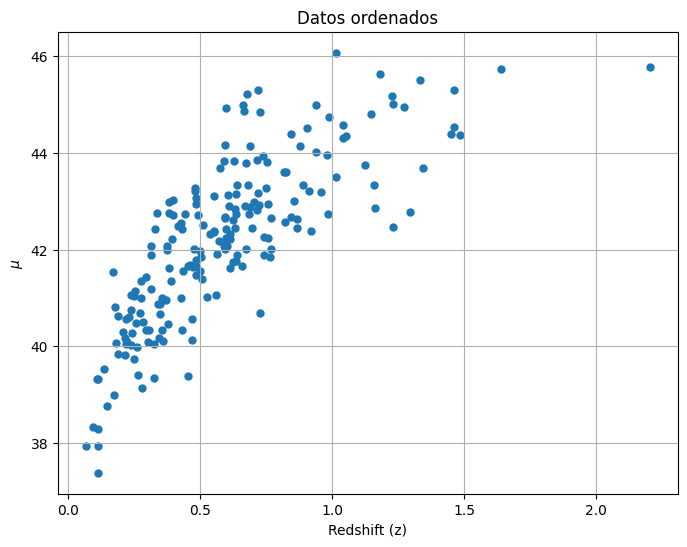

In [31]:
# Datos ordenados

plt.figure(figsize=(8,6))

plt.scatter(
    z,
    mu,
    s=25
)

plt.xlabel("Redshift (z)")
plt.ylabel(r"$\mu$")
plt.title("Datos ordenados")

plt.show()

In [33]:
# Parámetros cosmológicos

OMEGA_M = 0.3
OMEGA_L = 0.7

In [34]:
# Distancia cosmológica adimensional

def distancia_comovil(z):

    def integrando(zp):
        return 1.0 / np.sqrt(
            OMEGA_M * (1 + zp)**3 +
            OMEGA_L
        )

    valores = []

    for zi in np.atleast_1d(z):

        integral, _ = quad(
            integrando,
            0,
            zi
        )

        valores.append(integral)

    return np.array(valores)

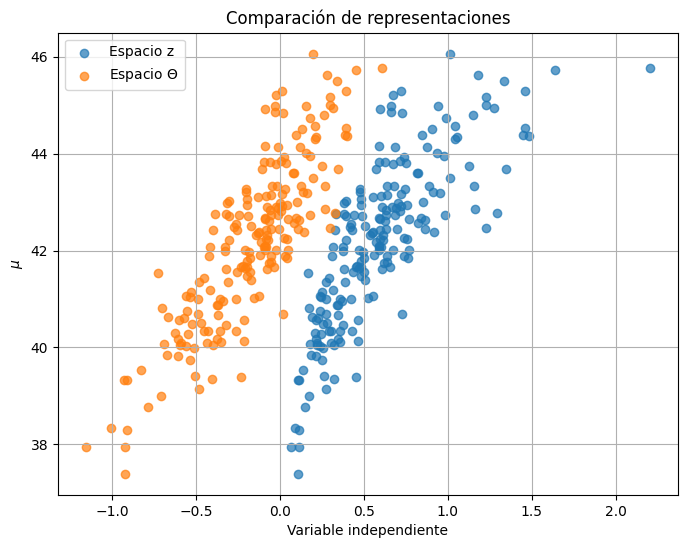

In [35]:
# Construcción del espacio Theta

theta = np.log10(
    (1 + z) * distancia_comovil(z)
)

# Comparación entre z y Theta

plt.figure(figsize=(8,6))

plt.scatter(
    z,
    mu,
    label="Espacio z",
    alpha=0.7
)

plt.scatter(
    theta,
    mu,
    label=r"Espacio $\Theta$",
    alpha=0.7
)

plt.xlabel("Variable independiente")
plt.ylabel(r"$\mu$")

plt.legend()

plt.title("Comparación de representaciones")

plt.show()

In [36]:
# Ajuste lineal en Theta

modelo_theta = LinearRegression()

modelo_theta.fit(
    theta.reshape(-1,1),
    mu
)

# Parámetros del modelo

pendiente = modelo_theta.coef_[0]

intercepto = modelo_theta.intercept_

print(f"Pendiente : {pendiente:.4f}")
print(f"Intercepto: {intercepto:.4f}")

Pendiente : 4.6293
Intercepto: 42.9792


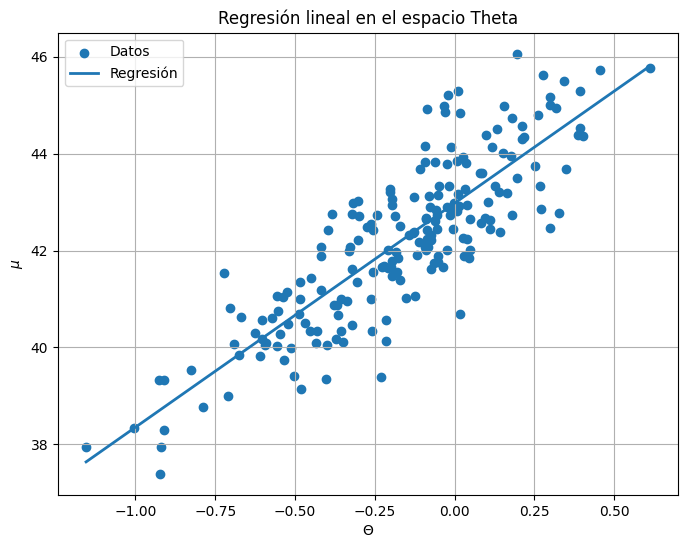

In [37]:
# Recta de mejor ajuste

theta_fit = np.linspace(
    theta.min(),
    theta.max(),
    300
)

mu_fit = modelo_theta.predict(
    theta_fit.reshape(-1,1)
)

plt.figure(figsize=(8,6))

plt.scatter(
    theta,
    mu,
    label="Datos"
)

plt.plot(
    theta_fit,
    mu_fit,
    linewidth=2,
    label="Regresión"
)

plt.xlabel(r"$\Theta$")
plt.ylabel(r"$\mu$")

plt.legend()

plt.title("Regresión lineal en el espacio Theta")

plt.show()

In [39]:
# Tamaños del conjunto de prueba

test_sizes = np.linspace(0.1, 0.5, 9)


# Evaluar R²

r2_theta = evaluar_r2(
    LinearRegression(),
    theta.reshape(-1,1),
    mu,
    test_sizes
)

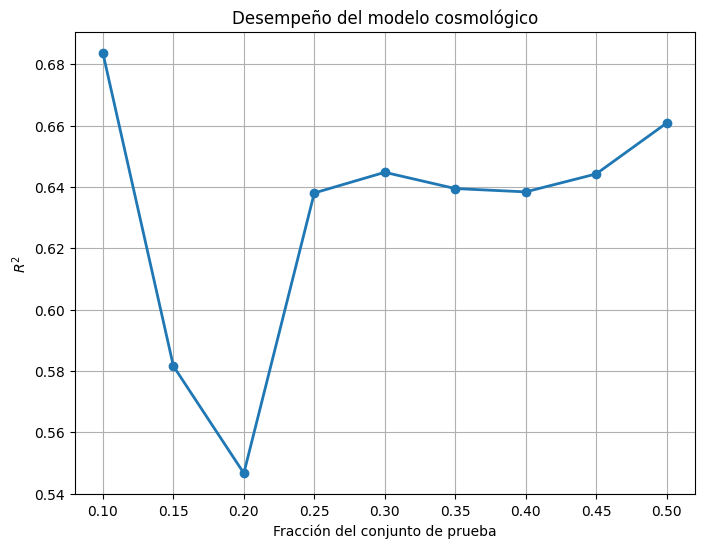

In [40]:
# Evolución del R²

plt.figure(figsize=(8,6))

plt.plot(
    test_sizes,
    r2_theta,
    marker="o",
    linewidth=2
)

plt.xlabel("Fracción del conjunto de prueba")
plt.ylabel(r"$R^2$")
plt.title("Desempeño del modelo cosmológico")

plt.grid(True)

plt.show()

In [41]:
# Resultados

resultados_theta = pd.DataFrame({
    "Test Size": np.round(test_sizes, 2),
    "R²": np.round(r2_theta, 4)
})

resultados_theta


# Estadísticas del modelo

print(f"R² promedio : {r2_theta.mean():.4f}")
print(f"R² máximo   : {r2_theta.max():.4f}")
print(f"R² mínimo   : {r2_theta.min():.4f}")
print(f"Desviación  : {r2_theta.std():.4f}")

R² promedio : 0.6309
R² máximo   : 0.6836
R² mínimo   : 0.5467
Desviación  : 0.0391
